# optiver-close — Phase 1 on Colab

Reproduces the whole Phase 1 pipeline from nothing but the repo and a Kaggle account:
clone → download the competition data → build the fixture → **verify the rebuild against the
committed manifest** → run the 78-test suite → run the baseline and ablation scripts → read
the numbers.

The headline you are reproducing: pooled OOF MAE in bps over 300 purged, embargoed,
forward-chained validation dates —

| baseline | MAE (bps) | vs predict-zero |
|---|---|---|
| ridge (14 features) | 6.3224 | **−0.0628** |
| constant median | 6.3850 | −0.0002 |
| predict-zero (floor) | 6.3852 | — |
| carry, raw | 9.1023 | +2.7171 |

**Runtime:** CPU is fine — nothing here uses a GPU. Pick a **high-RAM** runtime if offered
(the baseline run peaks at ~4.5 GB RSS; the standard VM's ~12 GB is enough, but with less
margin). End to end: roughly 10–15 minutes, most of it the Kaggle download and the ablation
script.

**You need:** a Kaggle account that has **joined** the *Optiver — Trading at the Close*
competition (kaggle.com/competitions/optiver-trading-at-the-close → Late Submission /
"I Understand and Accept"), and an API token (`kaggle.json` from kaggle.com → Settings →
Create New Token). Without having accepted the rules, the download in §2 returns a 403.

## 1. The repo

In [8]:
import os, subprocess
from pathlib import Path

REPO_USER = "Bromine185"
REPO_NAME = "optiver-close"
REPO = Path("/content") / REPO_NAME

if not REPO.exists():
    token = os.environ.get("GITHUB_TOKEN", "")   # empty string → no auth prefix
    auth  = f"{token}@" if token else ""
    url   = f"https://{auth}github.com/{REPO_USER}/{REPO_NAME}.git"
    subprocess.run(["git", "clone", "--depth", "1", url, str(REPO)], check=True)
    del auth, url
else:
    subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=False)

%cd {REPO}
!git log --oneline -1

/content/optiver-close
9f83c06 (grafted, HEAD -> master, origin/master, origin/HEAD) Colab notebook: authenticate via kagglehub, drop the kaggle.json flow


In [9]:
# Colab ships numpy/pandas/pyarrow/scipy/sklearn/matplotlib. pytest is the usual gap.
import importlib, subprocess, sys

for module, package in [("pytest", "pytest>=8.0")]:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

sys.path.insert(0, str(REPO / "src"))
import numpy as np, pandas as pd
print(f"python {sys.version.split()[0]}  numpy {np.__version__}  pandas {pd.__version__}")

python 3.13.15  numpy 2.1.3  pandas 2.2.3


## 2. The raw data, from Kaggle

`data/raw/` is gitignored (641 MB) and `data/fixtures/train.parquet` (130 MB) is too — what
the repo commits is `manifest.json`, the record a rebuild is checked against, plus the 4 MB
smoke fixture the tests run on. So Colab downloads the competition zip once and rebuilds.

Provide the API token one of two ways:
- **Colab secret** (better): key icon in the left sidebar → add `KAGGLE_USERNAME` and
  `KAGGLE_KEY` (the two fields inside your `kaggle.json`), grant this notebook access;
- **upload**: run the cell and pick your `kaggle.json` when asked.

In [10]:

import json as _json
import shutil

RAW = REPO / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

if not (RAW / "train.csv").exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "kagglehub"], check=True)
    import kagglehub

    try:
        src = Path(kagglehub.competition_download("optiver-trading-at-the-close"))
    except Exception as e:
        if "403" in str(e) or "Forbidden" in str(e):
            raise SystemExit(
                "403: this Kaggle account has not accepted the competition rules — "
                "visit kaggle.com/competitions/optiver-trading-at-the-close and join first."
            ) from e
        # no credentials found anywhere: interactive login (username + API token, no file)
        kagglehub.login()
        src = Path(kagglehub.competition_download("optiver-trading-at-the-close"))

    # kagglehub caches the files already unzipped; link them into data/raw/ where
    # scripts/build_fixture.py expects them (no 641 MB copy).
    for item in src.iterdir():
        dest = RAW / item.name
        if not dest.exists():
            dest.symlink_to(item)

print(f"train.csv: {(RAW / 'train.csv').stat().st_size / 1e6:.0f} MB")

100%|██████████| 201M/201M [00:01<00:00, 121MB/s]

Extracting files...


train.csv: 641 MB


## 3. Build the fixture, and check the rebuild against the committed manifest

The manifest the build writes is committed, so comparing the rebuilt one against
`git show HEAD:` is the reproduction report. Three classes of difference are expected
and harmless — timestamps / `build_seconds` / library `versions`; the parquet `sha256` /
`bytes`, which move with pyarrow's zstd and not with the data; and **last-ulp
floating-point noise** in the summary statistics, because a different numpy or CPU
reduces 5.2 M-row moments in a different order (observed: excess kurtosis agreeing to
2e-15 relative). So the check is structural, not textual — `optiver.manifest`, which has
its own tests: integers, strings and booleans (row counts, null counts, dtypes, coverage,
the gate's verdict) must match **exactly**; floats to 1e-9 relative, six orders looser
than version noise and six orders tighter than any real content drift. **A single
mismatch means the rebuild did not reproduce the fixture, and nothing downstream of it
should be trusted.**


In [11]:
!python scripts/build_fixture.py

reading /content/optiver-close/data/raw/train.csv (641 MB) in chunks of 1,000,000
  chunk 0: 1,000,000 rows
  chunk 1: 2,000,000 rows
  chunk 2: 3,000,000 rows
  chunk 3: 4,000,000 rows
  chunk 4: 5,000,000 rows
  chunk 5: 5,237,980 rows
  parsed in 13s

wrote data/fixtures/train.parquet  (131.0 MB, 5,237,980 rows)
wrote data/fixtures/train_smoke.parquet  (4.2 MB, 140,360 rows, 40 stocks x 64 dates)
wrote data/fixtures/manifest.json

target float32 gate: max |err| = 1.47e-05 bps (tol 0.001), zero-MAE shift = 2.5e-10 bps (tol 1e-06) -> ACCEPTED
zero-predictor MAE over the whole fixture: 6.407771 bps
stock-days missing: 964 of 96,200; partial auctions: 0
null targets: 88 (kept in the fixture, not dropped)


In [ ]:
# The reproduction report: the rebuilt manifest against the committed one (git HEAD),
# compared STRUCTURALLY by optiver.manifest — ints/strings/bools exact, floats to 1e-9
# relative, build-time / library-version / zstd-byte keys ignored. Same check as
# `python scripts/check_manifest.py`; a text diff of the JSON is not (a different numpy
# reduces 5.2 M-row moments in a different order and moves the last digit of kurtosis).
from optiver import manifest as M

report = M.check(REPO)
print(report.summary())
if not report.ok:
    raise SystemExit("the rebuild did not reproduce the fixture; do not trust anything below this cell")

man = _json.loads((REPO / "data" / "fixtures" / "manifest.json").read_text())
print(f"rows {man['rows']:,}  build {man['build_seconds']}s")


## 4. The test suite

78 tests. They pin the split guarantees (no date ever divided, embargo respected, forward
chaining strict — including on a date axis with holes), the target's definition (the
60-second horizon, the shared index leg), the null-handling policy, and determinism. With
the full fixture present, all 78 run; on a bare clone two would skip.

In [7]:
!python -m pytest -q

...EF...EEF.......E.FEEEEEEEEEEEE...................s................... [ 67%]
..................................                                       [100%]
==================================== ERRORS ====================================
___________ ERROR at setup of test_garch_same_label_is_bit_identical ___________

y = array([0.54742804, 1.37455226, 2.18422559, ..., 1.64353661, 1.01782302,
       0.83937622])

    def _fit_garch_t(y: np.ndarray) -> tuple[float, float, float, float]:
        """Fit GARCH(1,1) with Student-t innovations via `arch`. Returns (omega, a, b, nu)."""
        try:
>           from arch import arch_model
E           ModuleNotFoundError: No module named 'arch'

src/diffmodel/baselines/classical.py:505: ModuleNotFoundError

The above exception was the direct cause of the following exception:

fit_series = array([[[ 3.22809769e-03,  4.87614982e-03,  6.76567247e-03, ...,
          2.55294307e-03, -1.84324279e-03,  1.4712710...[ 1.31414000e+05,  5.59320000e+04,

## 5. Baselines — the honest floor and what beats it

`run_baselines.py` on the FULL preset: 5 folds × 60 validation dates, 5-date embargo,
expanding window. Peak ~4.5 GB RSS. Every number is a difference against predict-zero,
because the target is index-relative and near-zero-mean *by construction* — 6.4 bps MAE is
not a straw man, it is within 0.0002 bps of the best constant that exists.

In [ ]:
!python scripts/run_baselines.py --preset FULL

In [14]:
 !git -C /content/optiver-close pull --ff-only

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 2.65 KiB | 2.65 MiB/s, done.
From https://github.com/Bromine185/optiver-close
   9f83c06..323ac45  master     -> origin/master
Updating 9f83c06..323ac45
Fast-forward
 notebooks/colab_phase1.ipynb | 130 ++++++++++++++++++++++++++++---------------
 1 file changed, 86 insertions(+), 44 deletions(-)


In [15]:
rep = _json.loads((REPO / "reports" / "phase1_baselines.json").read_text())

print(f"{'model':<18s} {'MAE bps':>9s} {'vs zero':>9s} {'%':>7s}")
for row in sorted(rep["scorecard"], key=lambda r: r["mae_bps"]):
    print(f"{row['model']:<18s} {row['mae_bps']:9.4f} {-row['vs_zero_bps']:+9.4f} "
          f"{row['vs_zero_pct']:6.2f}%")
print(f"\nbest_model = {rep['best_model']}   runtime {rep['runtime_seconds']:.0f}s")

coef = pd.Series(rep["ridge_coefficients_mean"]).sort_values(key=abs, ascending=False)
print("\ntop ridge coefficients (mean over folds, standardized features):")
print(coef.head(6).round(3).to_string())

model                MAE bps   vs zero       %
ridge                 6.3224   -0.0628   0.98%
ridge_noscale         6.3231   -0.0620   0.97%
carry_shrunk          6.3830   -0.0022   0.03%
constant_median       6.3850   -0.0002   0.00%
zero                  6.3852   -0.0000   0.00%
carry_raw             9.1023   +2.7171 -42.55%

best_model = ridge   runtime 12s

top ridge coefficients (mean over folds, standardized features):
wap_minus_reference_bps   -2.558
reference_minus_mid_bps   -1.683
seconds_frac              -0.340
near_minus_wap_bps         0.239
seconds_frac_sq            0.222
far_is_missing            -0.133


## 6. Ablations

The slowest script: feature ablations for the ridge, the carry baseline's autocorrelation
analysis, and the per-stock spread. Skip this cell if you only wanted the floor and the
headline.

In [16]:
!python scripts/run_ablations.py --preset FULL

=== preset FULL  fixture train.parquet ===
drop_null_targets: dropped 88 of 5237980 rows with a null target

--- ablation: mean of 5 fold MAEs, bps ---
  shipped                6.32288  vs zero +0.06287   feature clip + target clip 60 + MAE rescale
  no_feature_clip        6.32878  vs zero +0.05697   no feature clip in fit OR predict
  clip_fit_only          6.33042  vs zero +0.05532   clip the fitted rows, predict unclipped
  clip_predict_only      6.32248  vs zero +0.06326   fit unclipped, clip the predicted rows
  no_target_clip         6.32307  vs zero +0.06268   fit_clip_bps = None
  target_clip_20         6.32191  vs zero +0.06383   fit_clip_bps = 20 instead of 60
  alpha_1e4              6.32269  vs zero +0.06305   ridge alpha 1e4
  alpha_1e6              6.32936  vs zero +0.05638   ridge alpha 1e6
  no_rescale             6.32366  vs zero +0.06209   no MAE-optimal rescale
  training sd without the clip, as a multiple of the sd with it: far_minus_wap_bps 46.7-73.3x, imbalance_ra

## 7. Read the reports

Both scripts write machine-readable JSON under `reports/` — the same files whose committed
copies back every number in `RESEARCH.md`. Colab's copies should agree with the committed
ones to reporting precision; fold-to-fold MAE genuinely varies by 1.3 bps (that is the
data, not noise — see "Known limitations" in CLAUDE.md), so compare pooled numbers, not
single folds.

In [18]:
for name in ("phase1_baselines.json", "phase1_ablations.json"):
    p = REPO / "reports" / name
    if not p.exists():
        print(f"{name}: not written (section skipped?)")
        continue
    d = subprocess.run(["git", "diff", "--stat", "--", str(p.relative_to(REPO))],
                       capture_output=True, text=True).stdout.strip()
    print(f"{name}: {'matches the committed copy' if not d else d}")

phase1_baselines.json: matches the committed copy
phase1_ablations.json: reports/phase1_ablations.json | 332 +++++++++++++++++++++---------------------
 1 file changed, 166 insertions(+), 166 deletions(-)


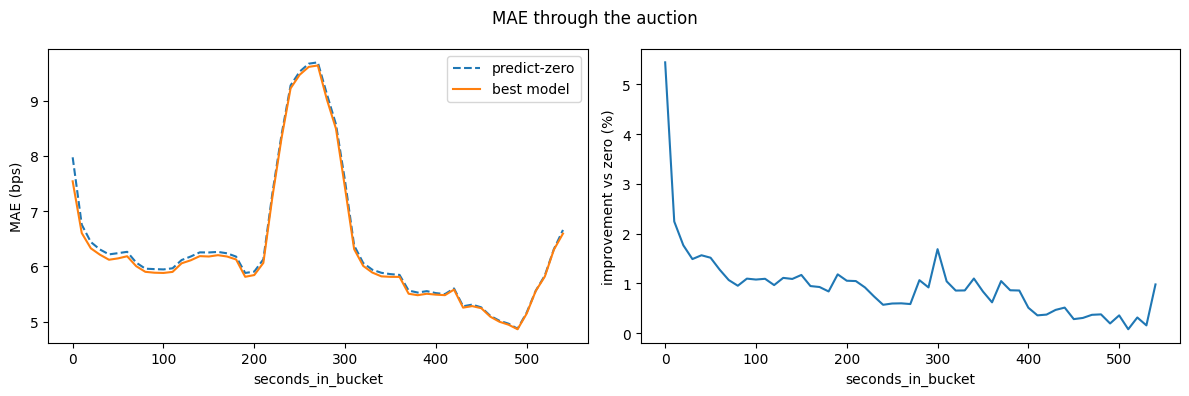

In [19]:
# Per-bucket picture: the ridge's edge is ~5% at the open of the auction and decays to ~1%.
import matplotlib.pyplot as plt

bs = pd.DataFrame(rep["by_seconds"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(bs["seconds_in_bucket"], bs["mae_zero"], ls="--", label="predict-zero")
axes[0].plot(bs["seconds_in_bucket"], bs["mae"], label="best model")
axes[0].set_ylabel("MAE (bps)"); axes[0].legend()
axes[1].plot(bs["seconds_in_bucket"], bs["improvement_pct"])
axes[1].set_ylabel("improvement vs zero (%)")
for ax in axes:
    ax.set_xlabel("seconds_in_bucket")
fig.suptitle("MAE through the auction")
plt.tight_layout(); plt.show()

---

### What NOT to conclude from a green run

Phase 1 is a harness and a floor. A successful reproduction here says the split is
trustworthy and the floor is honest — it says nothing about what a real model will do.
The ridge's −0.06 bps is 1% better than doing nothing; Phase 2 (LightGBM on rolling
features, optimising MAE directly) is where a model claim would come from, and it will be
scored by this same harness so the numbers stay comparable.

Nothing in this notebook needs to leave the VM — the fixture and reports are rebuilt from
the manifest anywhere. If you want to keep Colab's reports anyway:

```python
from google.colab import files
files.download("reports/phase1_baselines.json")
```